In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [ ]:
df = pd.read_csv("iris.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
# Drop Id column (not useful)
df = df.drop("Id", axis=1)

# Features (X) and Target (y)
X = df.drop("Species", axis=1)
y = df["Species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
df.shape

(150, 5)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


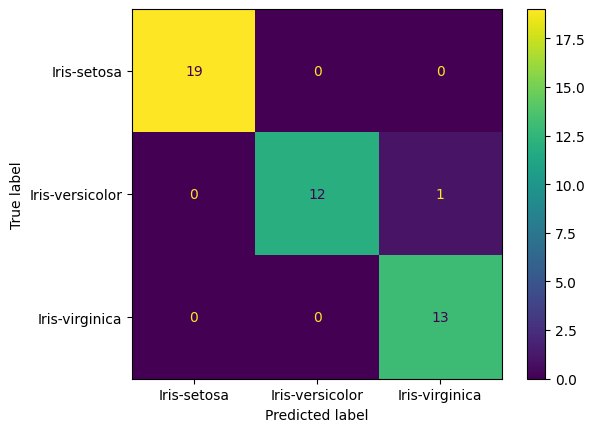

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9777777777777777
Error Rate: 0.022222222222222254
Precision: 0.9761904761904763
Recall: 0.9743589743589745


In [ ]:
import numpy as np

for i in range(len(cm)):
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    print(f"\nClass {i}:")
    print("TP:", TP)
    print("FP:", FP)
    print("FN:", FN)
    print("TN:", TN)


Class 0:
TP: 19
FP: 0
FN: 0
TN: 26

Class 1:
TP: 12
FP: 0
FN: 1
TN: 32

Class 2:
TP: 13
FP: 1
FN: 0
TN: 31


In [13]:
accuracy = np.trace(cm) / np.sum(cm)
error_rate = 1 - accuracy

precision_list = []
recall_list = []

for i in range(len(cm)):
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    precision_list.append(precision)
    recall_list.append(recall)

precision_avg = sum(precision_list) / len(precision_list)
recall_avg = sum(recall_list) / len(recall_list)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision_avg)
print("Recall:", recall_avg)

Accuracy: 0.9777777777777777
Error Rate: 0.022222222222222254
Precision: 0.9761904761904763
Recall: 0.9743589743589745
